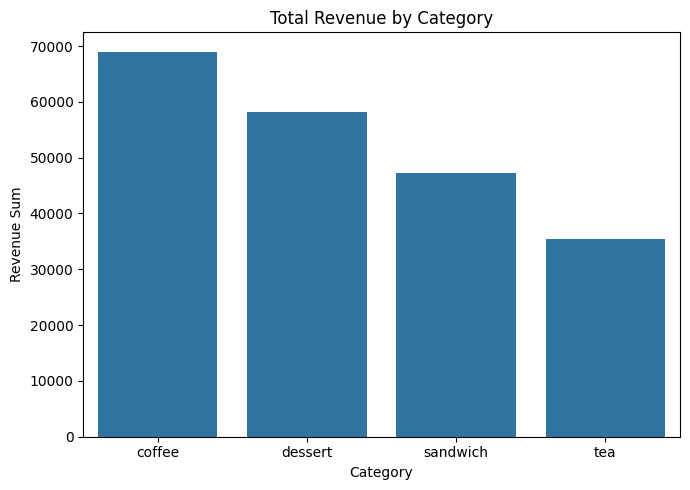

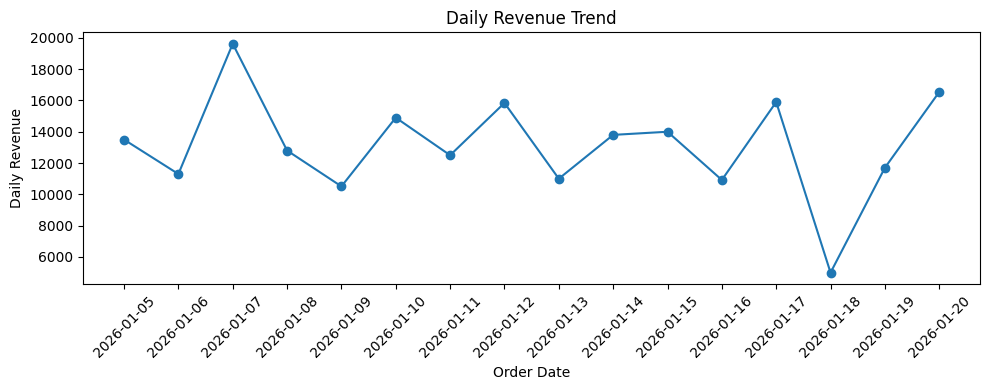

In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

customers = pd.read_csv("bootcamp_customers.csv", encoding='utf-8')
orders = pd.read_csv("bootcamp_orders.csv", encoding='utf-8')

orders = orders.drop_duplicates(subset=["order_id"], keep="first")
orders["discount_rate"] = orders["discount_rate"].fillna(0)
orders["revenue"] = orders["unit_price"] * orders["quantity"] * (1 - orders["discount_rate"])

merged_orders = orders.merge(customers, on="customer_id", how="left")
merged_orders["city"] = merged_orders["city"].fillna("UNKNOWN")

# 1.
category_revenue = merged_orders.groupby("category",as_index=False)["revenue"].sum()

plt.figure(figsize=(7,5))
sns.barplot(data=category_revenue, x="category", y="revenue")
plt.title("Total Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue Sum")
plt.tight_layout()
plt.show()

# 2.
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 

daily = merged_orders.groupby("order_date", as_index=False)["revenue"].sum()

plt.figure(figsize=(10,4))
plt.plot(daily["order_date"], daily["revenue"], marker="o")
plt.title("Daily Revenue Trend")
plt.xlabel("Order Date")
plt.ylabel("Daily Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()